# OBTAIN STAGE 

In [1]:
import os
import zipfile
import pandas as pd
from tqdm import tqdm

In [2]:
# List the zip's contents without extracting anything yet
zip_path = "../data/raw/FakeAVCeleb_v1.2.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    all_files = zip_ref.namelist()

print(f"Total files in zip: {len(all_files)}")
print("\nFirst 20 entries:")
for f in all_files[:20]:
    print(" -", f)

Total files in zip: 24110

First 20 entries:
 - FakeAVCeleb_v1.2/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id00476_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01076_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id01179_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id02005_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_10_id02342_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00518_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00761_wavtolip.mp4
 - FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00076/00109_12_id00987_wavtolip.mp4
 - FakeAVC

In [3]:
# Search for any CSV/metadata files
meta_candidates = [f for f in all_files if f.lower().endswith('.csv') or 'meta' in f.lower()]
print("Metadata candidates found:")
for f in meta_candidates:
    print(" -", f)

# Also inspect the top-level category folders
top_level = sorted(set(f.split('/')[1] for f in all_files if '/' in f and len(f.split('/')) > 1))
print("\nTop-level categories:")
for t in top_level:
    print(" -", t)

Metadata candidates found:
 - FakeAVCeleb_v1.2/meta_data.csv

Top-level categories:
 - 
 - FakeVideo-FakeAudio
 - FakeVideo-RealAudio
 - README.txt
 - RealVideo-FakeAudio
 - RealVideo-RealAudio
 - meta_data.csv


In [4]:
#Extract just the metadata CSV and README (tiny, safe)
small_files = ["FakeAVCeleb_v1.2/meta_data.csv", "FakeAVCeleb_v1.2/README.txt"]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for f in small_files:
        zip_ref.extract(f, path="../data/raw/")

print("Extracted:", small_files)

Extracted: ['FakeAVCeleb_v1.2/meta_data.csv', 'FakeAVCeleb_v1.2/README.txt']


In [5]:
df = pd.read_csv("../data/raw/FakeAVCeleb_v1.2/meta_data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(21566, 10)
['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']


,source,target1,target2,method,category,type,race,gender,path,Unnamed: 9
0,id00076,-,-,real,A,RealVideo-RealAudio,African,men,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
1,id00166,-,-,real,A,RealVideo-RealAudio,African,men,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
2,id00173,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
3,id00366,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...
4,id00391,-,-,real,A,RealVideo-RealAudio,African,men,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id...


In [6]:
# See the full, untruncated content of a few rows, especially the path columns
pd.set_option('display.max_colwidth', None)
print(df[['path', 'Unnamed: 9']].head(10))

# Distribution across type (our main label)
print("\n--- type ---")
print(df['type'].value_counts())

# Distribution across category (short code)
print("\n--- category ---")
print(df['category'].value_counts())

# Distribution across race and gender (relevant for balanced sampling + your Ethics Statement)
print("\n--- race ---")
print(df['race'].value_counts())

print("\n--- gender ---")
print(df['gender'].value_counts())

        path                                           Unnamed: 9
0  00109.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00076
1  00010.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00166
2  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00173
3  00118.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00366
4  00052.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00391
5  00099.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00475
6  00109.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00476
7  00206.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00478
8  00031.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00518
9  00092.mp4  FakeAVCeleb/RealVideo-RealAudio/African/men/id00701

--- type ---
type
FakeVideo-FakeAudio    10857
FakeVideo-RealAudio     9709
RealVideo-RealAudio      500
RealVideo-FakeAudio      500
Name: count, dtype: int64

--- category ---
category
D    10857
C     9709
A      500
B      500
Name: count, dtype: int64

--- race ---
ra

In [7]:
# Build the subset by sampling from the metadata, then matching to real zip filenames
import random
random.seed(42)  # reproducibility — important for your Methodology section

# Take all rows for the two scarce real categories
real_real = df[df['type'] == 'RealVideo-RealAudio']
real_fake_audio = df[df['type'] == 'RealVideo-FakeAudio']

# Sample 500 from each of the two abundant fake categories
fake_real_audio = df[df['type'] == 'FakeVideo-RealAudio'].sample(n=500, random_state=42)
fake_fake_audio = df[df['type'] == 'FakeVideo-FakeAudio'].sample(n=500, random_state=42)

subset_df = pd.concat([real_real, real_fake_audio, fake_real_audio, fake_fake_audio], ignore_index=True)

print(subset_df.shape)
print(subset_df['type'].value_counts())

(2000, 10)
type
RealVideo-RealAudio    500
RealVideo-FakeAudio    500
FakeVideo-RealAudio    500
FakeVideo-FakeAudio    500
Name: count, dtype: int64


In [8]:
# Match each subset row to its actual filename in the zip
def find_zip_path(row, all_files):
    # Build the folder prefix from Unnamed: 9, e.g. "FakeAVCeleb/RealVideo-RealAudio/African/men/id00076"
    folder_prefix = row['Unnamed: 9'].replace('FakeAVCeleb/', 'FakeAVCeleb_v1.2/')
    short_name = row['path'].replace('.mp4', '')  # e.g. "00109"
    
    # Find files in this folder that start with the short name (handles the longer real filenames)
    matches = [f for f in all_files if f.startswith(folder_prefix + '/') and short_name in f and f.endswith('.mp4')]
    return matches[0] if matches else None

subset_df['zip_path'] = subset_df.apply(lambda row: find_zip_path(row, all_files), axis=1)

# Check how many matched successfully
print(f"Matched: {subset_df['zip_path'].notna().sum()} / {len(subset_df)}")
subset_df[['type', 'path', 'Unnamed: 9', 'zip_path']].head(10)

Matched: 2000 / 2000


,type,path,Unnamed: 9,zip_path
0,RealVideo-RealAudio,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00076,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4
1,RealVideo-RealAudio,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00166,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166/00010.mp4
2,RealVideo-RealAudio,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00173,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00173/00118.mp4
3,RealVideo-RealAudio,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00366,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00366/00118.mp4
4,RealVideo-RealAudio,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00391,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00391/00052.mp4
5,RealVideo-RealAudio,00099.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00475,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00475/00099.mp4
6,RealVideo-RealAudio,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00476,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00476/00109.mp4
7,RealVideo-RealAudio,00206.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00478,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00478/00206.mp4
8,RealVideo-RealAudio,00031.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00518,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00518/00031.mp4
9,RealVideo-RealAudio,00092.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00701,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00701/00092.mp4


In [9]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    total_size = sum(zip_ref.getinfo(f).file_size for f in subset_df['zip_path'])

print(f"Estimated extracted size: {total_size / (1024**3):.2f} GB")

Estimated extracted size: 0.49 GB


In [10]:
extract_root = "../data/raw/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for f in tqdm(subset_df['zip_path'], desc="Extracting subset"):
        zip_ref.extract(f, path=extract_root)

print("Extraction complete.")

Extracting subset: 100%|██████████████████| 2000/2000 [00:06<00:00, 323.22it/s]

Extraction complete.


In [11]:
# Check that every extracted file actually exists on disk
subset_df['local_path'] = subset_df['zip_path'].apply(lambda p: os.path.join(extract_root, p))
missing = subset_df[~subset_df['local_path'].apply(os.path.exists)]

print(f"Successfully extracted: {len(subset_df) - len(missing)} / {len(subset_df)}")
if len(missing) > 0:
    print("Missing files:")
    print(missing[['type', 'zip_path']])

Successfully extracted: 2000 / 2000


In [12]:
subset_df.to_csv("../data/processed/subset_metadata.csv", index=False)
print("Saved subset_metadata.csv")

Saved subset_metadata.csv


# SCRUB STAGE 

In [13]:
# Imports + verify libraries
import cv2                          # OpenCV — handles reading video frames and image processing
import librosa                      # Librosa — loads and analyzes audio waveforms
import mediapipe as mp              # MediaPipe — Google's library for detecting faces/landmarks in images
from moviepy import VideoFileClip   # VideoFileClip — lets us open a video and pull out its audio track (moviepy v2+ dropped the old ".editor" import path)
import numpy as np                  # NumPy — handles arrays/numbers efficiently, used under the hood by cv2/librosa
from pathlib import Path            # Path — a cleaner way to build file paths than manual string joining

print("cv2:", cv2.__version__)      # print OpenCV's installed version, confirms it imported correctly
print("librosa:", librosa.__version__)  # print librosa's installed version, same reason
print("mediapipe ready")            # mediapipe doesn't expose __version__ the same way, so just confirm the import worked

cv2: 4.13.0
librosa: 0.11.0
mediapipe ready


In [14]:
# Set up folders for Scrub outputs
frames_dir = Path("../data/processed/frames")      # Path — where we'll save extracted face-frame images
audio_dir = Path("../data/processed/audio")         # Path — where we'll save extracted audio waveforms

frames_dir.mkdir(parents=True, exist_ok=True)       # mkdir — creates the folder (and any missing parent folders); exist_ok avoids an error if it already exists
audio_dir.mkdir(parents=True, exist_ok=True)        # mkdir — same, for the audio output folder

print("Folders ready:", frames_dir, audio_dir)      # print — confirms both paths so we can visually check they're correct

Folders ready: ../data/processed/frames ../data/processed/audio


In [15]:
face_cascade_path = "../models/haarcascade_frontalface_default.xml"  # face_cascade_path — points to our own downloaded copy instead of relying on the package's bundled files
face_detector = cv2.CascadeClassifier(face_cascade_path)              # CascadeClassifier — loads that pre-trained face detector so we can use it on images

print("Face detector loaded:", not face_detector.empty())             # empty() — checks the detector actually loaded correctly (True = loaded fine, so we print "not empty" = True means success)                        # empty() — checks the detector actually loaded correctly (True = loaded fine, so we print "not empty" = True means success)                    # print — simple confirmation the object was created without error

Face detector loaded: True


In [16]:
test_row = subset_df.iloc[0]                                          # iloc[0] — grabs the very first row of our subset table, just to test with
test_video_path = "../data/raw/" + test_row['zip_path']                # test_video_path — builds the full local path to that one video file we already extracted

print("Testing on:", test_video_path)                                  # print — shows us exactly which file we're about to test on

cap = cv2.VideoCapture(test_video_path)                                # VideoCapture — opens the video file so we can read frames from it one at a time
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))                   # CAP_PROP_FRAME_COUNT — asks OpenCV how many total frames are in this video
fps = cap.get(cv2.CAP_PROP_FPS)                                        # CAP_PROP_FPS — asks OpenCV how many frames per second the video plays at

print(f"Total frames: {frame_count}, FPS: {fps:.2f}")                  # print — shows us the video's basic stats, useful sanity check

cap.release()                                                          # release — closes the video file properly, freeing up memory/resources

Testing on: ../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4
Total frames: 251, FPS: 25.00


In [17]:
# Extract one frame and run face detection on it
cap = cv2.VideoCapture(test_video_path)                                # VideoCapture — reopens the video so we can grab a frame from it
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)                     # CAP_PROP_POS_FRAMES — jumps to the middle frame of the video (frame_count // 2), since the middle is usually a stable, representative moment
ret, frame = cap.read()                                                # read() — grabs that specific frame; ret tells us if it succeeded, frame is the actual image data
cap.release()                                                          # release — closes the video file now that we have our one frame

print("Frame read successfully:", ret)                                 # print — confirms whether grabbing the frame worked
print("Frame shape:", frame.shape)                                     # shape — shows the frame's dimensions (height, width, color channels), a basic sanity check

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)                         # cvtColor — converts the color frame to grayscale, since the face detector works on grayscale images
faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)  # detectMultiScale — scans the image at multiple sizes to find face-like regions; scaleFactor/minNeighbors are standard tuning values that balance accuracy vs. false positives

print("Faces detected:", len(faces))                                   # print — how many face regions were found (ideally exactly 1, since each clip is one person)
print("Face coordinates (x, y, w, h):", faces)                         # print — shows the bounding box(es) found: x,y = top-left corner, w,h = width/height of the box

Frame read successfully: True
Frame shape: (224, 224, 3)
Faces detected: 1
Face coordinates (x, y, w, h): [[ 65   5 124 124]]


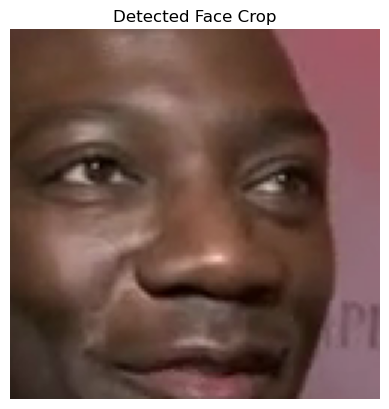

In [18]:
# Visually confirm by saving the detected face crop as an imageimport matplotlib.py
import matplotlib.pyplot as plt   # matplotlib.pyplot — lets us display images directly in the notebook

if len(faces) > 0:                                                     # if len(faces) > 0 — only proceed if at least one face was actually found
    x, y, w, h = faces[0]                                               # x, y, w, h — unpack the first detected face's bounding box coordinates
    face_crop = frame[y:y+h, x:x+w]                                     # frame[y:y+h, x:x+w] — slices out just the face region from the full frame using those coordinates
    face_crop_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)          # cvtColor BGR2RGB — OpenCV loads colors in BGR order, but matplotlib expects RGB, so we convert for correct display
    
    plt.imshow(face_crop_rgb)                                          # imshow — displays the cropped face image inline in the notebook
    plt.title("Detected Face Crop")                                    # title — labels the plot for clarity
    plt.axis('off')                                                    # axis('off') — hides the pixel-coordinate axes, since they're not useful here
    plt.show()                                                          # show — actually renders the plot in the notebook output
else:
    print("No face detected in this frame — we'll need to handle this case in our full pipeline")  # fallback message if detection failed on this particular frame

In [19]:
# Define the full per-clip processing function
N_FRAMES_PER_CLIP = 5  # N_FRAMES_PER_CLIP — how many frames we'll sample evenly from each video (5 gives temporal variety without extracting every single frame)

def extract_faces_from_video(video_path, output_dir, clip_id, n_frames=N_FRAMES_PER_CLIP):
    # extract_faces_from_video — our reusable function: takes one video, returns how many faces it successfully saved
    cap = cv2.VideoCapture(video_path)                                      # VideoCapture — opens the video file for reading
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))                   # CAP_PROP_FRAME_COUNT — total number of frames in this video

    if total_frames <= 0:                                                   # if total_frames <= 0 — guards against corrupt/unreadable videos
        cap.release()                                                       # release — close the file since we're bailing out early
        return 0                                                            # return 0 — signal that zero faces were saved for this clip

    frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)   # linspace — picks n_frames evenly spaced frame numbers across the whole video (e.g., start, ~25%, ~50%, ~75%, end)

    saved_count = 0                                                         # saved_count — tracks how many face crops we successfully saved for this clip
    for i, frame_idx in enumerate(frame_indices):                          # enumerate — loops through our chosen frame indices, i is just a counter (0,1,2...)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)                         # CAP_PROP_POS_FRAMES — jumps the video reader to this specific frame number
        ret, frame = cap.read()                                            # read() — actually grabs that frame; ret confirms success

        if not ret:                                                         # if not ret — skip this frame if it failed to read (corrupt frame)
            continue                                                        # continue — move on to the next frame index in the loop

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)                      # cvtColor — convert to grayscale, required by our face detector
        faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)  # detectMultiScale — run face detection on this frame

        if len(faces) > 0:                                                  # if len(faces) > 0 — only save if a face was actually found
            x, y, w, h = faces[0]                                          # faces[0] — take the first detected face (assumes one main subject per clip)
            face_crop = frame[y:y+h, x:x+w]                                # frame[y:y+h, x:x+w] — crop just the face region out of the full frame
            face_crop = cv2.resize(face_crop, (224, 224))                  # resize — standardize every face crop to 224x224 pixels, a common size for feeding into deep learning models later

            out_path = output_dir / f"{clip_id}_frame{i}.jpg"              # out_path — builds a unique filename per clip and frame number
            cv2.imwrite(str(out_path), face_crop)                          # imwrite — saves the cropped face image to disk as a .jpg file
            saved_count += 1                                               # saved_count += 1 — increment our success counter

    cap.release()                                                          # release — close the video file now that we're done with it
    return saved_count                                                     # return saved_count — report back how many faces we successfully saved for this clip

print("Function defined")                                                  # print — simple confirmation the function was created without error

Function defined


In [20]:
# Run face extraction on the full subset
results = []  # results — an empty list where we'll record how each clip was processed, for later analysis

for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Extracting faces"):
    # iterrows() — loops through subset_df one row at a time; idx is the row number, row is the row's data
    # tqdm(...) — wraps the loop to show a live progress bar since this processes 2000 clips
    video_path = "../data/raw/" + row['zip_path']                          # video_path — builds the full local path to this clip's video file
    clip_id = f"{idx}_{row['type']}"                                       # clip_id — a unique identifier combining the row number and category, used to name saved files

    n_saved = extract_faces_from_video(video_path, frames_dir, clip_id)    # extract_faces_from_video — calls our function from Cell 7 on this one clip

    results.append({                                                       # append — adds a record of this clip's outcome to our results list
        'index': idx,                                                      # index — which row this was, so we can trace back to subset_df later
        'type': row['type'],                                              # type — the label (RealVideo-RealAudio, etc.), carried through for reference
        'clip_id': clip_id,                                                # clip_id — same unique ID used in the saved filenames
        'faces_saved': n_saved                                            # faces_saved — how many face crops were successfully extracted (0 to N_FRAMES_PER_CLIP)
    })

results_df = pd.DataFrame(results)                                         # DataFrame — converts our list of results into a proper table for easy analysis

print(f"Clips with 0 faces detected: {(results_df['faces_saved'] == 0).sum()}")           # sum() — counts how many clips had zero successful face extractions (potential problem clips)
print(f"Total face images saved: {results_df['faces_saved'].sum()}")                       # sum() — total count of all face images saved across every clip
print(f"Average faces per clip: {results_df['faces_saved'].mean():.2f}")                   # mean() — average number of faces saved per clip (out of a max of 5)

Extracting faces: 100%|████████████████████| 2000/2000 [02:05<00:00, 16.00it/s]

Clips with 0 faces detected: 50
Total face images saved: 8772
Average faces per clip: 4.39


In [21]:
# Inspect the clips with zero faces detected
zero_face_clips = results_df[results_df['faces_saved'] == 0]                # results_df[...] — filters our results table down to only the rows where faces_saved equals 0

print(f"Number of clips with 0 faces: {len(zero_face_clips)}")              # print — confirms the count matches what we saw above
print("\nBreakdown by type:")                                               # print — a header for the next line
print(zero_face_clips['type'].value_counts())                               # value_counts() — shows how these 50 failures are distributed across our 4 categories (important: if failures cluster in one category, that's a bias risk)

Number of clips with 0 faces: 50

Breakdown by type:
type
RealVideo-FakeAudio    16
RealVideo-RealAudio    15
FakeVideo-FakeAudio    12
FakeVideo-RealAudio     7
Name: count, dtype: int64


In [22]:
# Drop the 50 problem clips and finalize our clean subset
clean_subset_df = subset_df[~subset_df.index.isin(zero_face_clips['index'])].copy()  # ~subset_df.index.isin(...) — keeps only rows whose index is NOT in our zero_face_clips list; .copy() avoids a pandas warning about modifying a filtered view

print(f"Clean subset size: {len(clean_subset_df)}")                                   # print — should be 2000 - 50 = 1950
print(clean_subset_df['type'].value_counts())                                         # value_counts() — confirms the new counts per category after dropping the 50

Clean subset size: 1950
type
FakeVideo-RealAudio    493
FakeVideo-FakeAudio    488
RealVideo-RealAudio    485
RealVideo-FakeAudio    484
Name: count, dtype: int64


In [23]:
# Define the audio extraction function
def extract_audio_from_video(video_path, output_dir, clip_id):
    # extract_audio_from_video — our reusable function: takes one video, saves its audio track, returns True/False for success
    try:                                                                    # try — lets us attempt this and gracefully handle any failure (some clips may have no audio track at all)
        video = VideoFileClip(video_path)                                  # VideoFileClip — opens the video file using moviepy, which can access both video and audio streams
        audio = video.audio                                                # video.audio — extracts just the audio portion of the clip

        if audio is None:                                                  # if audio is None — some videos genuinely have no audio track
            video.close()                                                  # close — releases the video file's resources
            return False                                                   # return False — signal that audio extraction failed for this clip

        out_path = output_dir / f"{clip_id}.wav"                          # out_path — builds the output filename for this clip's audio
        audio.write_audiofile(str(out_path), logger=None)                 # write_audiofile — saves the audio as a .wav file; logger=None silences moviepy's verbose per-file printout

        video.close()                                                      # close — releases the video file's resources now that we're done
        return True                                                        # return True — signal successful extraction

    except Exception as e:                                                 # except Exception as e — catches ANY error (corrupt file, codec issue, etc.) so one bad clip doesn't crash our whole loop
        return False                                                       # return False — treat any error as a failed extraction for this clip

print("Audio function defined")                                            # print — confirms the function was created without error

Audio function defined


In [24]:
# Run audio extraction on the full clean subset
audio_results = []  # audio_results — an empty list where we'll record each clip's audio extraction outcome

for idx, row in tqdm(clean_subset_df.iterrows(), total=len(clean_subset_df), desc="Extracting audio"):
    # iterrows() — loops through clean_subset_df one row at a time
    # tqdm(...) — shows a live progress bar for this 1950-clip loop
    video_path = "../data/raw/" + row['zip_path']                          # video_path — full local path to this clip's video file
    clip_id = f"{idx}_{row['type']}"                                       # clip_id — same unique ID convention we used for face crops, so audio/face files can be matched later

    success = extract_audio_from_video(video_path, audio_dir, clip_id)     # extract_audio_from_video — calls our Cell 11 function on this one clip

    audio_results.append({                                                 # append — records this clip's outcome
        'index': idx,                                                      # index — row number, to trace back to clean_subset_df
        'type': row['type'],                                              # type — the category label, carried through
        'clip_id': clip_id,                                                # clip_id — matches the saved .wav filename
        'audio_extracted': success                                        # audio_extracted — True/False, whether this clip's audio saved successfully
    })

audio_results_df = pd.DataFrame(audio_results)                             # DataFrame — converts our results list into a table

print(f"Successful audio extractions: {audio_results_df['audio_extracted'].sum()} / {len(audio_results_df)}")  # sum() on booleans — counts how many True values, i.e. successes
print(f"\nFailures by type:")                                              # print — header for the next line
print(audio_results_df[~audio_results_df['audio_extracted']]['type'].value_counts())  # ~audio_extracted — filters to only failures, then breaks them down by category

Extracting audio: 100%|████████████████████| 1950/1950 [10:09<00:00,  3.20it/s]

Successful audio extractions: 1950 / 1950

Failures by type:
Series([], Name: count, dtype: int64)


In [25]:
# Build the final merged dataset table
results_df_indexed = results_df.set_index('index')                          # set_index — makes 'index' the row label so we can align it with clean_subset_df by matching row numbers

final_df = clean_subset_df.copy()                                           # copy() — start from our clean 1950-row subset, so we don't accidentally modify the original
final_df['clip_id'] = final_df.index.map(lambda i: f"{i}_{final_df.loc[i, 'type']}")  # map — rebuilds the same clip_id string for every row, matching what we used when saving files

final_df['faces_saved'] = final_df.index.map(results_df_indexed['faces_saved'])  # map — pulls in how many face crops were saved for each clip, matched by row index

final_df['audio_extracted'] = True                                          # audio_extracted — we already know all 1950 succeeded, so we can just set this directly instead of merging

final_df['face_dir'] = str(frames_dir)                                      # face_dir — records where the face images live, so future code knows where to look
final_df['audio_path'] = final_df['clip_id'].apply(lambda cid: str(audio_dir / f"{cid}.wav"))  # audio_path — builds the exact path to each clip's saved .wav file

print(final_df.shape)                                                       # shape — should be (1950, however many columns we now have)
final_df[['type', 'clip_id', 'faces_saved', 'audio_extracted', 'audio_path']].head(10)  # head(10) — preview the key new columns to sanity check everything lined up correctly

(1950, 17)


,type,clip_id,faces_saved,audio_extracted,audio_path
0,RealVideo-RealAudio,0_RealVideo-RealAudio,3,True,../data/processed/audio/0_RealVideo-RealAudio.wav
1,RealVideo-RealAudio,1_RealVideo-RealAudio,3,True,../data/processed/audio/1_RealVideo-RealAudio.wav
2,RealVideo-RealAudio,2_RealVideo-RealAudio,5,True,../data/processed/audio/2_RealVideo-RealAudio.wav
3,RealVideo-RealAudio,3_RealVideo-RealAudio,2,True,../data/processed/audio/3_RealVideo-RealAudio.wav
4,RealVideo-RealAudio,4_RealVideo-RealAudio,4,True,../data/processed/audio/4_RealVideo-RealAudio.wav
5,RealVideo-RealAudio,5_RealVideo-RealAudio,1,True,../data/processed/audio/5_RealVideo-RealAudio.wav
6,RealVideo-RealAudio,6_RealVideo-RealAudio,5,True,../data/processed/audio/6_RealVideo-RealAudio.wav
7,RealVideo-RealAudio,7_RealVideo-RealAudio,1,True,../data/processed/audio/7_RealVideo-RealAudio.wav
8,RealVideo-RealAudio,8_RealVideo-RealAudio,4,True,../data/processed/audio/8_RealVideo-RealAudio.wav
9,RealVideo-RealAudio,9_RealVideo-RealAudio,2,True,../data/processed/audio/9_RealVideo-RealAudio.wav


In [26]:
# Save this as our final Scrub output
final_df.to_csv("../data/processed/scrubbed_dataset.csv", index=False)     # to_csv — saves our final merged table to disk, this becomes THE reference file for Explore and Model
print("Saved scrubbed_dataset.csv")                                        # print — confirmation
print(f"Final dataset: {len(final_df)} clips, {final_df['faces_saved'].sum()} face images, {final_df['audio_extracted'].sum()} audio files")  # print — a one-line summary of everything Scrub produced

Saved scrubbed_dataset.csv
Final dataset: 1950 clips, 8772 face images, 1950 audio files


## Explore Stage 

In [27]:
# Load our Scrub output and set up plotting

import matplotlib.pyplot as plt                                    # matplotlib.pyplot — for creating all our charts and image grids
import matplotlib.image as mpimg                                   # matplotlib.image — lets us load and display saved .jpg face images
import librosa.display                                             # librosa.display — has built-in functions for plotting waveforms/spectrograms
import seaborn as sns                                               # seaborn — makes nicer-looking statistical plots (built on top of matplotlib)

final_df = pd.read_csv("../data/processed/scrubbed_dataset.csv")   # read_csv — reloads our Scrub output, so Explore can run independently without re-doing extraction

print(final_df.shape)                                               # shape — confirms we're starting with (1950, however many columns)
final_df.head()                                                     # head() — quick visual check that everything loaded correctly

(1950, 17)


,source,target1,target2,method,category,type,race,gender,path,Unnamed: 9,zip_path,local_path,clip_id,faces_saved,audio_extracted,face_dir,audio_path
0,id00076,-,-,real,A,RealVideo-RealAudio,African,men,00109.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00076,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4,../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00076/00109.mp4,0_RealVideo-RealAudio,3,True,../data/processed/frames,../data/processed/audio/0_RealVideo-RealAudio.wav
1,id00166,-,-,real,A,RealVideo-RealAudio,African,men,00010.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00166,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166/00010.mp4,../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00166/00010.mp4,1_RealVideo-RealAudio,3,True,../data/processed/frames,../data/processed/audio/1_RealVideo-RealAudio.wav
2,id00173,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00173,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00173/00118.mp4,../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00173/00118.mp4,2_RealVideo-RealAudio,5,True,../data/processed/frames,../data/processed/audio/2_RealVideo-RealAudio.wav
3,id00366,-,-,real,A,RealVideo-RealAudio,African,men,00118.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00366,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00366/00118.mp4,../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00366/00118.mp4,3_RealVideo-RealAudio,2,True,../data/processed/frames,../data/processed/audio/3_RealVideo-RealAudio.wav
4,id00391,-,-,real,A,RealVideo-RealAudio,African,men,00052.mp4,FakeAVCeleb/RealVideo-RealAudio/African/men/id00391,FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00391/00052.mp4,../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/African/men/id00391/00052.mp4,4_RealVideo-RealAudio,4,True,../data/processed/frames,../data/processed/audio/4_RealVideo-RealAudio.wav


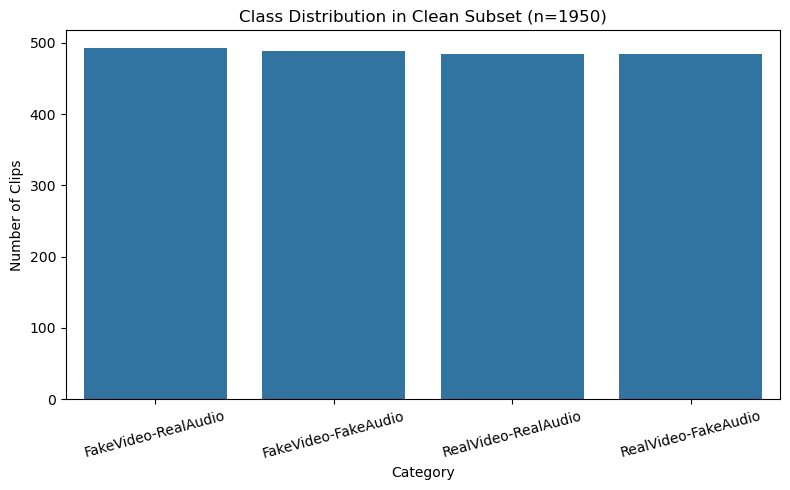

In [28]:
# Class distribution visualization
fig, ax = plt.subplots(figsize=(8, 5))                             # subplots — creates a figure and axis to draw on; figsize controls the plot's size in inches

sns.countplot(data=final_df, x='type', order=final_df['type'].value_counts().index, ax=ax)  # countplot — automatically counts and bars each category; order sorts bars biggest to smallest

ax.set_title("Class Distribution in Clean Subset (n=1950)")        # set_title — labels the chart
ax.set_xlabel("Category")                                          # set_xlabel — labels the x-axis
ax.set_ylabel("Number of Clips")                                   # set_ylabel — labels the y-axis
plt.xticks(rotation=15)                                            # xticks rotation — angles the category labels slightly so long names don't overlap
plt.tight_layout()                                                 # tight_layout — automatically adjusts spacing so labels aren't cut off
plt.savefig("../outputs/figures/class_distribution.png", dpi=150)  # savefig — saves this chart as an image file, ready to paste into your report (dpi=150 for print-quality resolution)
plt.show()                                                          # show — displays the chart in the notebook

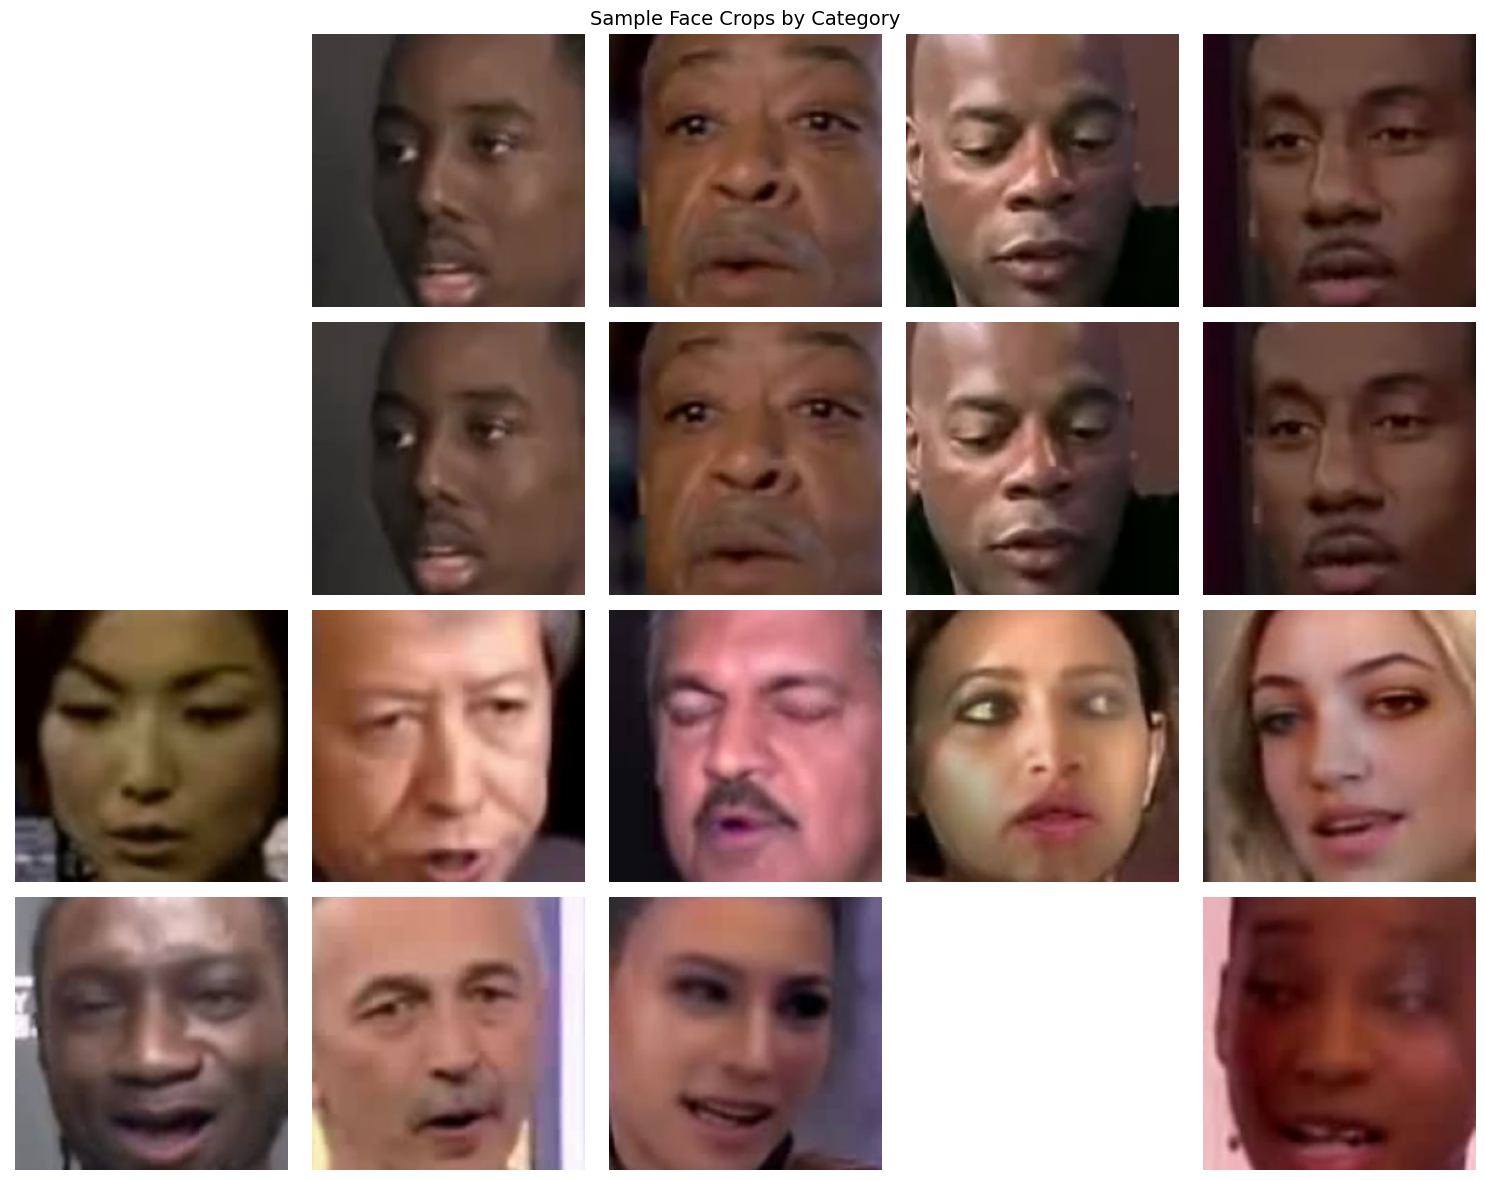

In [29]:
# Display a grid of sample face crops from each category

import os                                                            # os — lets us list files inside our frames folder

categories = final_df['type'].unique()                              # unique() — gets the 4 distinct category names from our dataset

fig, axes = plt.subplots(4, 5, figsize=(15, 12))                    # subplots(4, 5, ...) — creates a 4-row (one per category) by 5-column (5 sample images) grid of small plots

for row_idx, category in enumerate(categories):                     # enumerate — loops through categories, row_idx tracks which row we're filling (0,1,2,3)
    category_clips = final_df[final_df['type'] == category].head(5) # head(5) — grabs the first 5 clips belonging to this category

    for col_idx, (_, clip) in enumerate(category_clips.iterrows()): # enumerate + iterrows — loops through those 5 clips, col_idx tracks which column (0-4)
        frame_path = f"{clip['face_dir']}/{clip['clip_id']}_frame0.jpg"  # frame_path — builds the path to that clip's first saved face crop (frame0)

        if os.path.exists(frame_path):                              # os.path.exists — checks the file is actually there before trying to load it
            img = mpimg.imread(frame_path)                          # imread — loads the image file as pixel data
            axes[row_idx, col_idx].imshow(img)                      # imshow — draws the image into this specific grid cell
        
        axes[row_idx, col_idx].axis('off')                          # axis('off') — hides the pixel-coordinate axes for a cleaner look
        if col_idx == 0:                                            # if col_idx == 0 — only label the leftmost image in each row, to avoid clutter
            axes[row_idx, col_idx].set_ylabel(category, fontsize=10, rotation=0, labelpad=60, va='center')  # set_ylabel — labels this row with its category name

plt.suptitle("Sample Face Crops by Category", fontsize=14)          # suptitle — an overall title for the whole grid of images
plt.tight_layout()                                                  # tight_layout — adjusts spacing so nothing overlaps
plt.savefig("../outputs/figures/sample_faces_by_category.png", dpi=150)  # savefig — saves this figure for your report
plt.show()                                                          # show — displays it in the notebook

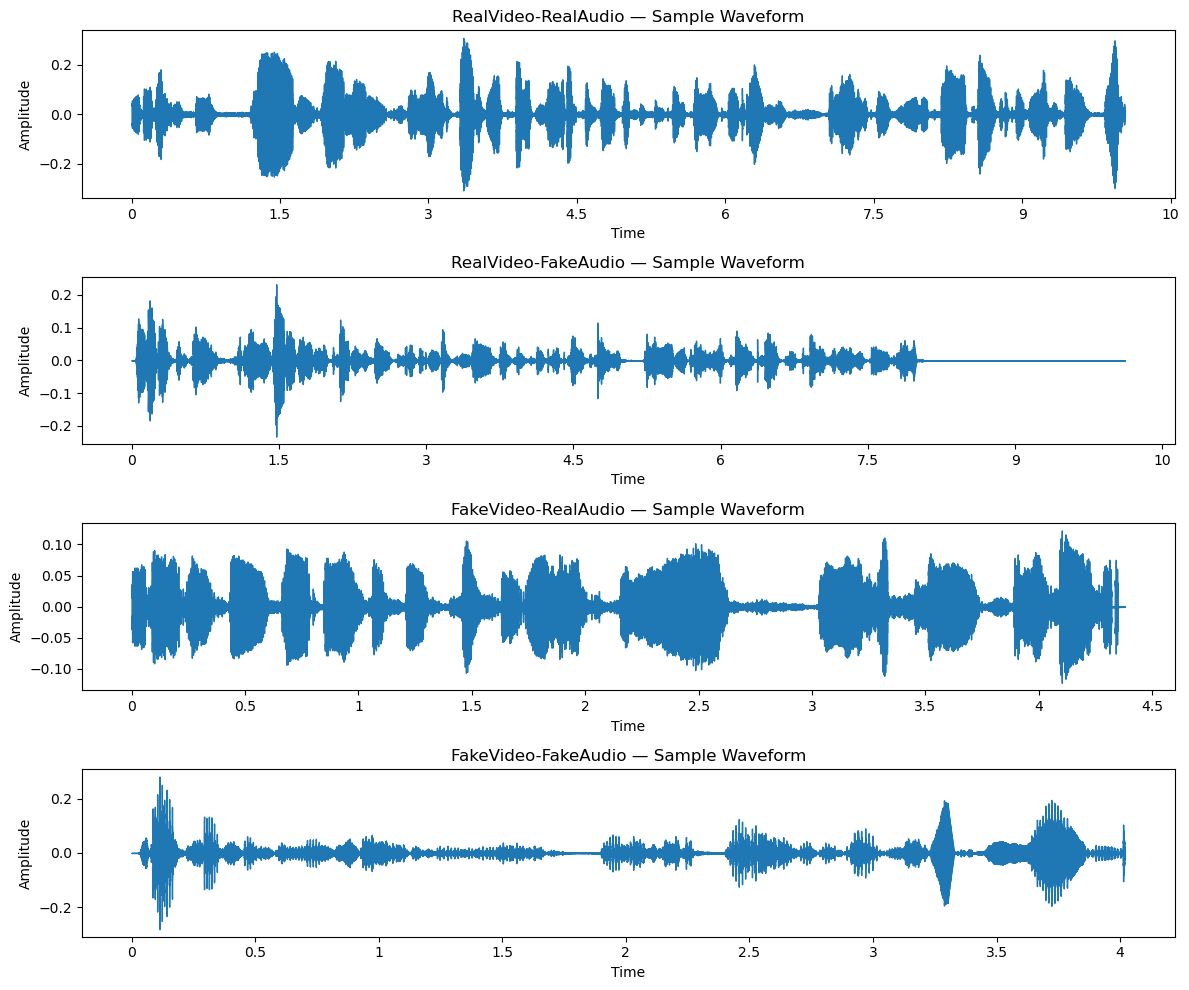

In [30]:
# Compare waveforms across categories

fig, axes = plt.subplots(4, 1, figsize=(12, 10))                    # subplots(4, 1, ...) — creates 4 stacked plots, one row per category

for idx, category in enumerate(categories):                         # enumerate — loops through our 4 categories, idx tracks the row (0-3)
    sample_clip = final_df[final_df['type'] == category].iloc[0]    # iloc[0] — grabs just the first clip from this category as our example

    y, sr = librosa.load(sample_clip['audio_path'], sr=None)        # librosa.load — reads the .wav file; y is the actual waveform data (array of numbers), sr is the sample rate; sr=None keeps the file's original sample rate

    librosa.display.waveshow(y, sr=sr, ax=axes[idx])                # waveshow — plots the waveform (amplitude over time) into this specific subplot
    axes[idx].set_title(f"{category} — Sample Waveform")            # set_title — labels this subplot with its category name
    axes[idx].set_ylabel("Amplitude")                                # set_ylabel — labels the y-axis (how loud the sound is at each moment)

plt.tight_layout()                                                   # tight_layout — adjusts spacing so titles/labels don't overlap
plt.savefig("../outputs/figures/waveform_comparison.png", dpi=150)  # savefig — saves this figure for your report
plt.show()                                                            # show — displays it in the notebook

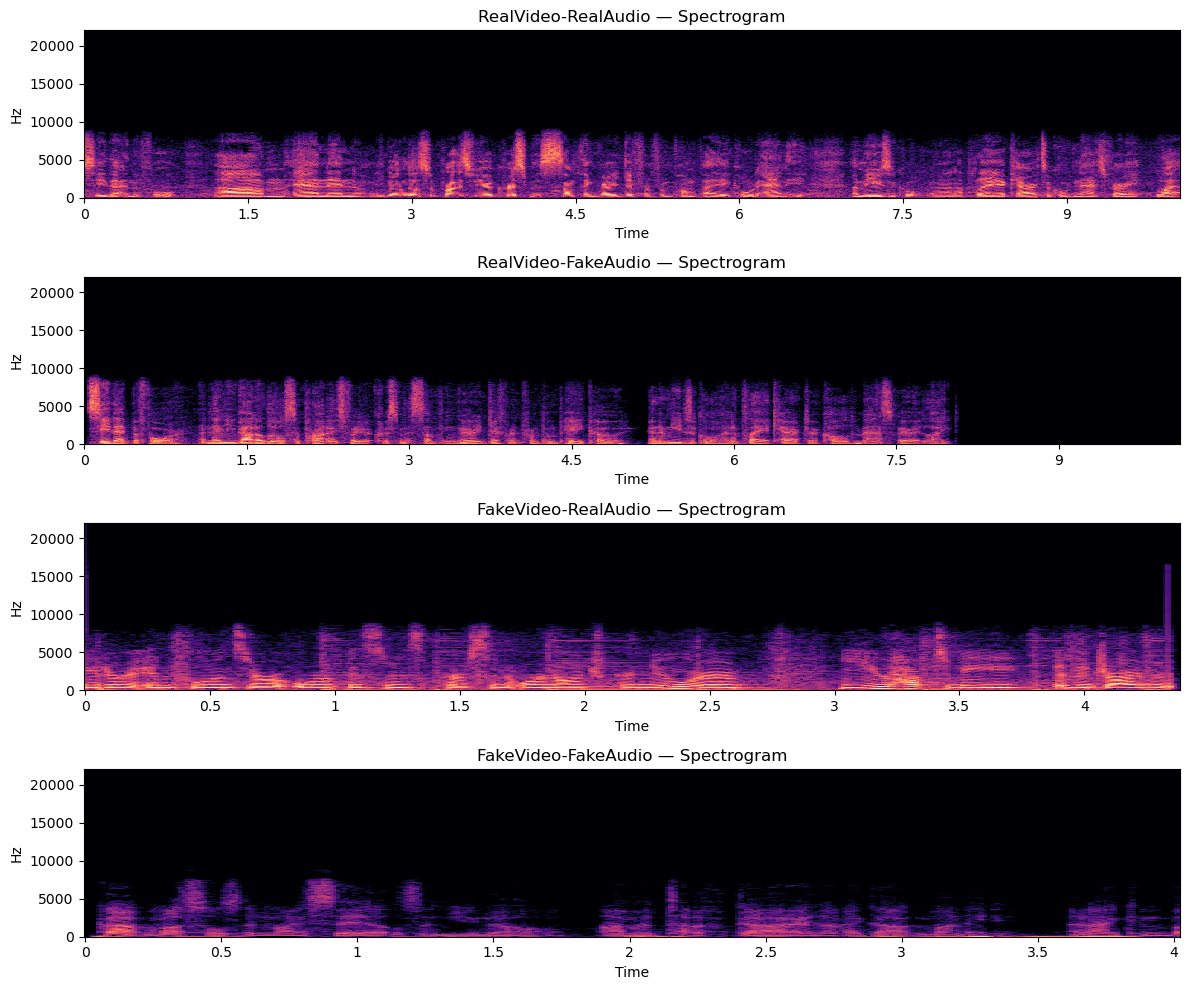

In [31]:
# Compare spectrograms across categories (more informative than raw waveforms)
fig, axes = plt.subplots(4, 1, figsize=(12, 10))                    # subplots — same 4-row layout as before

for idx, category in enumerate(categories):                         # enumerate — loops through the 4 categories
    sample_clip = final_df[final_df['type'] == category].iloc[0]    # iloc[0] — same sample clip as Cell 4, for direct comparison

    y, sr = librosa.load(sample_clip['audio_path'], sr=None)        # load — reads the audio waveform again

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)  # stft — converts the waveform into a spectrogram (frequency content over time); amplitude_to_db converts it to decibels, a more perceptually meaningful scale

    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx])  # specshow — draws the spectrogram; x_axis/y_axis add proper time/frequency labels
    axes[idx].set_title(f"{category} — Spectrogram")                # set_title — labels this subplot

plt.tight_layout()                                                   # tight_layout — adjusts spacing
plt.savefig("../outputs/figures/spectrogram_comparison.png", dpi=150)  # savefig — saves for your report
plt.show()                                                            # show — displays in the notebook

In [32]:
# Compute audio duration statistics across all categories
durations = []                                                       # durations — an empty list to collect duration info for every clip

for idx, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Computing durations"):
    # iterrows() — loops through every clip in our final dataset
    # tqdm — progress bar, since this touches all 1950 audio files
    try:                                                              # try — in case any file has an issue loading
        y, sr = librosa.load(row['audio_path'], sr=None)             # load — reads the audio file
        duration = len(y) / sr                                       # len(y) / sr — total samples divided by samples-per-second = duration in seconds
        durations.append({'type': row['type'], 'duration': duration})  # append — records this clip's category and duration
    except:                                                           # except — catches any read failure so the loop doesn't crash
        pass                                                          # pass — just skip this clip silently, it was already flagged as successful earlier so failures here should be rare

duration_df = pd.DataFrame(durations)                                 # DataFrame — converts our list into a table

print(duration_df.groupby('type')['duration'].describe())             # groupby + describe — shows count/mean/std/min/max duration stats, broken down by category

Computing durations: 100%|████████████████| 1950/1950 [00:09<00:00, 208.24it/s]

                     count      mean       std   min   25%       50%     75%  \
type                                                                           
FakeVideo-FakeAudio  488.0  4.581780  1.317334  1.93  3.85  4.359989  5.1400   
FakeVideo-RealAudio  493.0  6.002715  2.081868  3.96  4.54  5.300000  6.7200   
RealVideo-FakeAudio  484.0  6.621858  2.530950  4.04  4.76  5.800000  7.5525   
RealVideo-RealAudio  485.0  6.543215  2.527867  3.96  4.68  5.720000  7.4800   

                       max  
type                        
FakeVideo-FakeAudio  14.08  
FakeVideo-RealAudio  15.64  
RealVideo-FakeAudio  17.76  
RealVideo-RealAudio  17.68  


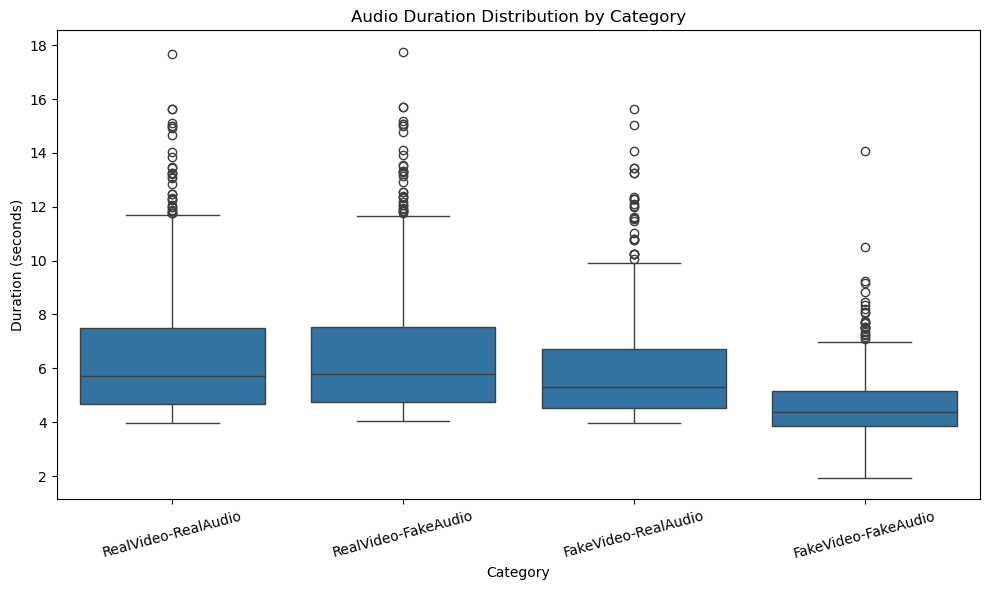

In [33]:
# Visualize duration distribution by category
fig, ax = plt.subplots(figsize=(10, 6))                              # subplots — creates our figure/axis
sns.boxplot(data=duration_df, x='type', y='duration', ax=ax)         # boxplot — shows the spread (median, quartiles, outliers) of durations for each category side-by-side

ax.set_title("Audio Duration Distribution by Category")              # set_title — labels the chart
ax.set_xlabel("Category")                                             # set_xlabel — labels x-axis
ax.set_ylabel("Duration (seconds)")                                   # set_ylabel — labels y-axis
plt.xticks(rotation=15)                                                # xticks rotation — angles labels slightly for readability
plt.tight_layout()                                                     # tight_layout — adjusts spacing
plt.savefig("../outputs/figures/duration_distribution.png", dpi=150)  # savefig — saves for your report
plt.show()                                                              # show — displays it

In [34]:
# Statistical test for duration differences
from scipy import stats                                              # scipy.stats — provides statistical test functions

groups = [duration_df[duration_df['type'] == t]['duration'].values for t in duration_df['type'].unique()]
# groups — builds a separate list of duration values for each of our 4 categories, needed as input for the test below

f_stat, p_value = stats.f_oneway(*groups)                            # f_oneway — runs a one-way ANOVA test, checking if the means across all 4 groups are significantly different from each other; * unpacks our list of 4 groups as separate arguments

print(f"ANOVA F-statistic: {f_stat:.2f}")                            # print — the F-statistic; larger values suggest bigger differences between group means
print(f"P-value: {p_value:.2e}")                                     # print — the p-value in scientific notation; a very small p-value (typically < 0.05) means the difference is statistically significant, not just random chance

if p_value < 0.05:                                                    # if p_value < 0.05 — the standard threshold for statistical significance
    print("\n→ Duration differs significantly across categories (p < 0.05)")  # print — plain-language interpretation
else:
    print("\n→ No significant difference in duration across categories")

ANOVA F-statistic: 92.27
P-value: 7.83e-56

→ Duration differs significantly across categories (p < 0.05)


## Model

In [35]:
# Load our data + import PyTorch libraries
import torch                                                          # torch — the core PyTorch library for building/running neural networks
import torchvision.transforms as transforms                          # transforms — tools for preprocessing images before feeding them into a model
from torchvision.models import resnet18, ResNet18_Weights             # resnet18 — the pretrained image model we'll use; ResNet18_Weights — lets us load its official pretrained weights
import torchaudio                                                     # torchaudio — PyTorch's library for audio, includes pretrained speech models

final_df = pd.read_csv("../data/processed/scrubbed_dataset.csv")     # read_csv — reload our Scrub output fresh, so Model starts independently

device = torch.device("cpu")                                         # device — tells PyTorch to run computations on the CPU (we don't have a dedicated GPU on this Mac, so CPU it is — slower but works fine for our dataset size)
print("Using device:", device)                                       # print — confirms which device we're running on

Using device: cpu


In [36]:
# Load the pretrained ResNet18 (face/image feature extractor)
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)            # resnet18(weights=...) — downloads and loads ResNet18 pretrained on ImageNet (1000 everyday object categories) — we're reusing its learned visual features, not its final classification layer
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])          # Sequential(*...[:-1]) — rebuilds the model WITHOUT its final classification layer, so it outputs raw 512-dimensional feature embeddings instead of class predictions
resnet.eval()                                                          # eval() — puts the model in "evaluation mode" (disables training-specific behavior like dropout), since we're only using it to extract features, not training it further
resnet.to(device)                                                     # to(device) — moves the model onto our chosen device (CPU)

image_transform = transforms.Compose([                                # Compose — chains together a sequence of preprocessing steps to apply to every image
    transforms.ToPILImage(),                                          # ToPILImage — converts our OpenCV/numpy image into the PIL format torchvision expects
    transforms.Resize((224, 224)),                                    # Resize — ensures every image is exactly 224x224 (ResNet's expected input size)
    transforms.ToTensor(),                                            # ToTensor — converts the image into a PyTorch tensor (the numeric format models operate on)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize — rescales pixel values using ImageNet's known statistics, since that's what ResNet was trained on
])

print("ResNet18 loaded, ready to extract 512-dim face embeddings")   # print — confirmation

ResNet18 loaded, ready to extract 512-dim face embeddings


In [37]:
# Load the pretrained Wav2Vec2 (audio feature extractor)
bundle = torchaudio.pipelines.WAV2VEC2_BASE                          # WAV2VEC2_BASE — a "bundle" object that packages together the pretrained Wav2Vec2 model + its expected settings (like sample rate) in one convenient object
wav2vec_model = bundle.get_model()                                   # get_model() — actually downloads and builds the pretrained Wav2Vec2 model from that bundle
wav2vec_model.eval()                                                  # eval() — same as before, puts the model in evaluation mode since we're only extracting features, not training it
wav2vec_model.to(device)                                             # to(device) — moves the model onto our CPU

expected_sample_rate = bundle.sample_rate                            # sample_rate — Wav2Vec2 expects audio at a specific sample rate (16000 Hz); we'll need to resample our audio if it differs

print(f"Wav2Vec2 loaded, expects {expected_sample_rate} Hz audio")   # print — confirmation, and tells us the exact sample rate we need to match

Wav2Vec2 loaded, expects 16000 Hz audio


In [38]:
# Test both feature extractors, robustly finding an existing frame
import glob                                                            # glob — lets us search for files matching a pattern, instead of guessing an exact filename

test_row = final_df.iloc[0]                                           # iloc[0] — grab the first clip in our dataset to test on

# --- Test image embedding ---
matching_frames = glob.glob(f"{test_row['face_dir']}/{test_row['clip_id']}_frame*.jpg")  # glob — finds ALL frame files that exist for this clip, regardless of which frame numbers succeeded
print("Found frame files:", matching_frames)                          # print — shows us exactly which frames actually got saved for this clip

test_frame_path = matching_frames[0]                                  # matching_frames[0] — just use whichever frame file actually exists, first one found
test_img = cv2.imread(test_frame_path)                                # imread — loads that real image
print("Image loaded successfully:", test_img is not None)             # print — confirms it's not None this time

test_img_tensor = image_transform(test_img).unsqueeze(0)              # image_transform(...) — applies preprocessing; unsqueeze(0) — adds batch dimension

with torch.no_grad():                                                  # no_grad() — no gradient tracking needed, we're just extracting features
    image_embedding = resnet(test_img_tensor)                         # resnet(...) — run through ResNet18
    image_embedding = image_embedding.flatten()                      # flatten() — reshape to 1D vector

print("Image embedding shape:", image_embedding.shape)                # print — should show torch.Size([512])

# --- Test audio embedding (using librosa instead of torchaudio.load) ---
test_y, test_sr = librosa.load(test_row['audio_path'], sr=expected_sample_rate)  # librosa.load — reads the audio file AND resamples it to our target rate in one step (sr=expected_sample_rate handles this automatically, no separate resampler needed)

test_waveform = torch.from_numpy(test_y).unsqueeze(0)                 # from_numpy — converts librosa's numpy array into a PyTorch tensor; unsqueeze(0) — adds the "channel" dimension Wav2Vec2 expects (1 audio channel)

with torch.no_grad():                                                  # no_grad() — no gradient tracking needed
    audio_features, _ = wav2vec_model.extract_features(test_waveform) # extract_features — runs audio through Wav2Vec2
    audio_embedding = audio_features[-1].mean(dim=1).flatten()        # take last layer, average over time, flatten to 1D

print("Audio embedding shape:", audio_embedding.shape)                # print — shows resulting audio embedding size

Found frame files: ['../data/processed/frames/0_RealVideo-RealAudio_frame2.jpg', '../data/processed/frames/0_RealVideo-RealAudio_frame1.jpg', '../data/processed/frames/0_RealVideo-RealAudio_frame4.jpg']
Image loaded successfully: True
Image embedding shape: torch.Size([512])
Audio embedding shape: torch.Size([768])


In [39]:
# Define the full per-clip feature extraction function
def extract_clip_features(row):
    # extract_clip_features — takes one row from our dataset, returns its combined image+audio embedding, or None if something fails
    try:                                                                # try — wraps everything so one bad clip doesn't crash the whole batch
        # --- Image embedding: average across all available frames ---
        matching_frames = glob.glob(f"{row['face_dir']}/{row['clip_id']}_frame*.jpg")  # glob — finds every saved frame for this clip (could be 1 to 5)

        if len(matching_frames) == 0:                                   # if len == 0 — safety check, shouldn't happen since we already filtered these out in Scrub, but just in case
            return None                                                 # return None — signal failure for this clip

        frame_embeddings = []                                           # frame_embeddings — collects one embedding per available frame
        for frame_path in matching_frames:                              # for frame_path in matching_frames — loop through every frame this clip has
            img = cv2.imread(frame_path)                                # imread — load the frame
            if img is None:                                             # if img is None — skip if somehow unreadable
                continue                                                # continue — move to next frame
            img_tensor = image_transform(img).unsqueeze(0)              # image_transform + unsqueeze — preprocess and add batch dimension
            with torch.no_grad():                                       # no_grad — no gradient tracking needed
                emb = resnet(img_tensor).flatten()                      # resnet(...) — extract this frame's embedding
            frame_embeddings.append(emb)                                # append — add to our list

        if len(frame_embeddings) == 0:                                  # if len == 0 — all frames failed to load somehow
            return None                                                 # return None — signal failure

        image_embedding = torch.stack(frame_embeddings).mean(dim=0)     # stack — combines our list of embeddings into one tensor; mean(dim=0) — averages across all frames, giving one representative 512-dim vector per clip

        # --- Audio embedding ---
        y, sr = librosa.load(row['audio_path'], sr=expected_sample_rate)  # load — reads and resamples the audio in one step
        waveform = torch.from_numpy(y).unsqueeze(0)                     # from_numpy + unsqueeze — converts to the tensor format Wav2Vec2 expects

        with torch.no_grad():                                           # no_grad — no gradient tracking needed
            audio_features, _ = wav2vec_model.extract_features(waveform)  # extract_features — run through Wav2Vec2
            audio_embedding = audio_features[-1].mean(dim=1).flatten()  # take last layer, average over time, flatten

        # --- Combine both modalities into one feature vector ---
        combined = torch.cat([image_embedding, audio_embedding])        # cat — concatenates the two embeddings end-to-end into one long vector (512 + 768 = 1280 dimensions)
        return combined.numpy()                                         # .numpy() — converts from a PyTorch tensor to a plain numpy array, easier to store/save

    except Exception as e:                                              # except Exception as e — catches any unexpected error for this clip
        return None                                                     # return None — signal failure, we'll count and handle these afterward

print("Feature extraction function defined")                            # print — confirmation

Feature extraction function defined


In [40]:
# Run feature extraction on all clips, with periodic checkpointing
import pickle                                                          # pickle — lets us save/load Python objects (like our list of embeddings) directly to disk

features_list = []                                                     # features_list — collects each clip's combined embedding
labels_list = []                                                       # labels_list — collects each clip's category label, in matching order
clip_ids_list = []                                                     # clip_ids_list — collects each clip's ID, so we can trace failures back later

checkpoint_every = 200                                                 # checkpoint_every — how often (in clips) we save progress to disk, as a safety net

for i, (idx, row) in enumerate(tqdm(final_df.iterrows(), total=len(final_df), desc="Extracting features")):
    # enumerate — i is a simple 0,1,2... counter; idx, row — same as before, row number and row data
    # tqdm — progress bar for this long-running loop

    features = extract_clip_features(row)                              # extract_clip_features — our Cell 5 function, does all the heavy lifting for one clip

    if features is not None:                                           # if features is not None — only keep successful extractions
        features_list.append(features)                                 # append — add this clip's combined embedding
        labels_list.append(row['type'])                                # append — add this clip's label, same position as its embedding
        clip_ids_list.append(row['clip_id'])                            # append — add this clip's ID for traceability

    if (i + 1) % checkpoint_every == 0:                                 # if (i+1) % checkpoint_every == 0 — every 200 clips, save our progress
        with open("../data/processed/features_checkpoint.pkl", "wb") as f:  # open(...'wb') — opens a file in write-binary mode, needed for pickle
            pickle.dump({'features': features_list, 'labels': labels_list, 'clip_ids': clip_ids_list}, f)  # dump — saves our three lists together as one checkpoint file

print(f"\nSuccessfully extracted features for {len(features_list)} / {len(final_df)} clips")  # print — final success count

# Final save
with open("../data/processed/features_checkpoint.pkl", "wb") as f:      # open — save one final time to make sure everything is captured
    pickle.dump({'features': features_list, 'labels': labels_list, 'clip_ids': clip_ids_list}, f)  # dump — same as above

print("Saved to features_checkpoint.pkl")                               # print — confirmation

Extracting features: 100%|███████████████| 1950/1950 [1:15:25<00:00,  2.32s/it]


Successfully extracted features for 1950 / 1950 clips
Saved to features_checkpoint.pkl


In [41]:
# Load features and prepare train/test split
with open("../data/processed/features_checkpoint.pkl", "rb") as f:    # open(...'rb') — opens our saved file in read-binary mode
    data = pickle.load(f)                                              # pickle.load — loads our saved features/labels/clip_ids back into memory

X = np.array(data['features'])                                         # np.array — converts our list of embeddings into one big 2D array (rows=clips, columns=1280 features each)
y = np.array(data['labels'])                                           # np.array — converts our list of labels into an array

print("Feature matrix shape:", X.shape)                                # print — should show (1950, 1280): 1950 clips, 1280 features each (512 image + 768 audio)
print("Label distribution:")                                           # print — header
print(pd.Series(y).value_counts())                                     # value_counts — confirms our 4 categories are still balanced after feature extraction

from sklearn.model_selection import train_test_split                   # train_test_split — scikit-learn's tool for splitting data into training and testing sets
from sklearn.preprocessing import LabelEncoder                         # LabelEncoder — converts text labels ("RealVideo-RealAudio", etc.) into numbers, which models require

label_encoder = LabelEncoder()                                         # LabelEncoder() — creates the encoder object
y_encoded = label_encoder.fit_transform(y)                             # fit_transform — learns the mapping from text labels to numbers, and applies it

print("\nLabel encoding:")                                             # print — header
for i, cls in enumerate(label_encoder.classes_):                       # enumerate — loops through each class and its assigned number
    print(f"  {i} = {cls}")                                            # print — shows us the mapping, e.g. "0 = FakeVideo-FakeAudio"

X_train, X_test, y_train, y_test = train_test_split(                   # train_test_split — splits our data into separate training and testing portions
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded   # test_size=0.2 — 80% train / 20% test; random_state=42 — reproducibility; stratify — ensures each split has proportional representation of all 4 classes
)

print(f"\nTrain set: {X_train.shape[0]} clips")                        # print — confirms training set size
print(f"Test set: {X_test.shape[0]} clips")                            # print — confirms test set size

Feature matrix shape: (1950, 1280)
Label distribution:
FakeVideo-RealAudio    493
FakeVideo-FakeAudio    488
RealVideo-RealAudio    485
RealVideo-FakeAudio    484
Name: count, dtype: int64

Label encoding:
  0 = FakeVideo-FakeAudio
  1 = FakeVideo-RealAudio
  2 = RealVideo-FakeAudio
  3 = RealVideo-RealAudio

Train set: 1560 clips
Test set: 390 clips


In [42]:
# Define the classifier model
import torch.nn as nn                                                  # torch.nn — PyTorch's module for building neural network layers

class DeepfakeClassifier(nn.Module):                                   # class DeepfakeClassifier(nn.Module) — defines our own custom model by extending PyTorch's base Module class
    def __init__(self, input_dim=1280, num_classes=4):                 # __init__ — runs once when we create the model, sets up its layers; input_dim=1280 matches our combined embedding size, num_classes=4 matches our categories
        super().__init__()                                             # super().__init__() — required setup step for any PyTorch model
        self.network = nn.Sequential(                                  # Sequential — chains layers together in order
            nn.Linear(input_dim, 256),                                 # Linear(1280, 256) — a fully-connected layer, compresses our 1280 features down to 256
            nn.ReLU(),                                                 # ReLU — an activation function, introduces non-linearity so the model can learn complex patterns, not just straight lines
            nn.Dropout(0.3),                                           # Dropout(0.3) — randomly "turns off" 30% of neurons during training, helps prevent overfitting since we only have 1560 training clips
            nn.Linear(256, 64),                                        # Linear(256, 64) — further compresses down to 64
            nn.ReLU(),                                                 # ReLU — same reasoning
            nn.Linear(64, num_classes)                                 # Linear(64, 4) — final layer, outputs 4 raw scores, one per category
        )

    def forward(self, x):                                              # forward — defines what happens when we actually run data through the model
        return self.network(x)                                        # return — passes input through our layer chain, returns the output

model = DeepfakeClassifier(input_dim=1280, num_classes=len(label_encoder.classes_))  # DeepfakeClassifier(...) — creates an instance of our model, matching our actual data dimensions
print(model)                                                            # print — displays the model's architecture, a good sanity check

DeepfakeClassifier(
  (network): Sequential(
    (0): Linear(in_features=1280, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [43]:
# Prepare data as PyTorch tensors and set up training
X_train_tensor = torch.FloatTensor(X_train)                            # FloatTensor — converts our training features from numpy into PyTorch's tensor format, required for training
y_train_tensor = torch.LongTensor(y_train)                             # LongTensor — converts our training labels; LongTensor specifically because classification labels need to be integers
X_test_tensor = torch.FloatTensor(X_test)                              # FloatTensor — same conversion for test features
y_test_tensor = torch.LongTensor(y_test)                               # LongTensor — same conversion for test labels

criterion = nn.CrossEntropyLoss()                                      # CrossEntropyLoss — the standard loss function for multi-class classification; measures how wrong the model's predictions are
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)             # Adam — an optimization algorithm that adjusts the model's internal weights to reduce loss; lr=0.001 is the "learning rate," how big each adjustment step is (a common safe default)

n_epochs = 50                                                           # n_epochs — how many times we'll show the model the entire training set

print(f"Training for {n_epochs} epochs on {X_train_tensor.shape[0]} clips")  # print — confirms our setup before training starts

Training for 50 epochs on 1560 clips


In [44]:
# The actual training loop
train_losses = []                                                       # train_losses — tracks loss at each epoch, so we can plot it afterward
test_accuracies = []                                                    # test_accuracies — tracks accuracy on our held-out test set at each epoch

for epoch in range(n_epochs):                                          # for epoch in range(n_epochs) — repeat the training process 50 times
    model.train()                                                       # train() — puts the model in "training mode" (enables dropout, etc.)
    optimizer.zero_grad()                                               # zero_grad() — clears old gradient calculations from the previous step, required before each new one

    outputs = model(X_train_tensor)                                    # model(...) — runs ALL training data through the model at once, gets raw predictions
    loss = criterion(outputs, y_train_tensor)                          # criterion(...) — compares predictions to true labels, calculates how wrong we are

    loss.backward()                                                     # backward() — calculates how to adjust every weight in the model to reduce this loss (backpropagation)
    optimizer.step()                                                    # step() — actually applies those weight adjustments

    train_losses.append(loss.item())                                   # append — records this epoch's loss value (.item() converts from tensor to plain number)

    model.eval()                                                        # eval() — switches to evaluation mode (disables dropout) for testing
    with torch.no_grad():                                               # no_grad() — no need to track gradients when just evaluating
        test_outputs = model(X_test_tensor)                            # model(...) — run the model on our held-out test set
        test_preds = torch.argmax(test_outputs, dim=1)                 # argmax — picks the category with the highest predicted score, for each clip
        accuracy = (test_preds == y_test_tensor).float().mean().item() # compares predictions to true labels, calculates the fraction correct
        test_accuracies.append(accuracy)                               # append — records this epoch's test accuracy

    if (epoch + 1) % 10 == 0:                                          # if (epoch+1) % 10 == 0 — every 10 epochs, print an update so we can watch progress
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {loss.item():.4f} — Test Accuracy: {accuracy:.4f}")  # print — shows current loss and accuracy

print("\nTraining complete!")                                          # print — final confirmation
print(f"Final test accuracy: {test_accuracies[-1]:.4f}")               # print — the accuracy from the very last epoch

Epoch 10/50 — Loss: 1.1242 — Test Accuracy: 0.6385
Epoch 20/50 — Loss: 0.7851 — Test Accuracy: 0.6667
Epoch 30/50 — Loss: 0.5869 — Test Accuracy: 0.7564
Epoch 40/50 — Loss: 0.4384 — Test Accuracy: 0.8000
Epoch 50/50 — Loss: 0.3608 — Test Accuracy: 0.8051

Training complete!
Final test accuracy: 0.8051


Classification Report:
                     precision    recall  f1-score   support

FakeVideo-FakeAudio       0.89      0.92      0.90        97
FakeVideo-RealAudio       0.73      0.69      0.71        99
RealVideo-FakeAudio       0.90      0.90      0.90        97
RealVideo-RealAudio       0.70      0.72      0.71        97

           accuracy                           0.81       390
          macro avg       0.80      0.81      0.80       390
       weighted avg       0.80      0.81      0.80       390



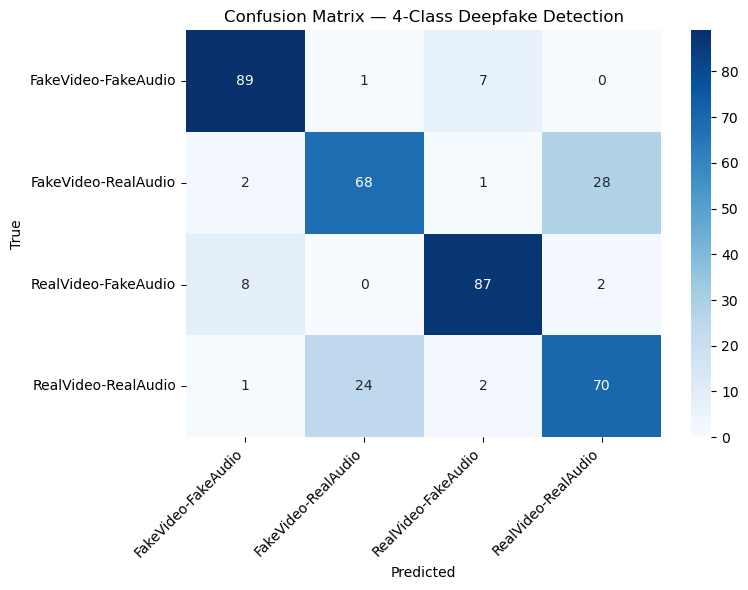

In [45]:
# Confusion matrix and detailed classification report
from sklearn.metrics import confusion_matrix, classification_report   # confusion_matrix — shows exactly which classes get mixed up with which; classification_report — gives per-class precision/recall/F1 scores

model.eval()                                                            # eval() — evaluation mode, no dropout
with torch.no_grad():                                                   # no_grad() — no gradient tracking needed
    final_outputs = model(X_test_tensor)                                # model(...) — run the model on our test set one more time
    final_preds = torch.argmax(final_outputs, dim=1).numpy()           # argmax — get predicted class per clip; .numpy() — convert to numpy array for use with sklearn

print("Classification Report:")                                        # print — header
print(classification_report(y_test, final_preds, target_names=label_encoder.classes_))  # classification_report — shows precision/recall/F1 for each of our 4 categories by name

cm = confusion_matrix(y_test, final_preds)                              # confusion_matrix — builds a table: rows=true labels, columns=predicted labels, cells=counts

fig, ax = plt.subplots(figsize=(8, 6))                                  # subplots — creates our figure
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                     # heatmap — visualizes the confusion matrix as a color-coded grid; annot=True shows the actual numbers; fmt='d' formats them as integers; cmap='Blues' sets the color scheme
            xticklabels=label_encoder.classes_,                        # xticklabels — labels the columns (predicted classes) with our real category names
            yticklabels=label_encoder.classes_, ax=ax)                 # yticklabels — labels the rows (true classes) similarly
ax.set_xlabel("Predicted")                                              # set_xlabel — labels the x-axis
ax.set_ylabel("True")                                                   # set_ylabel — labels the y-axis
ax.set_title("Confusion Matrix — 4-Class Deepfake Detection")          # set_title — labels the chart
plt.xticks(rotation=45, ha='right')                                     # xticks rotation — angles the category names so they don't overlap
plt.tight_layout()                                                      # tight_layout — adjusts spacing
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)        # savefig — saves this key figure for your report
plt.show()                                                               # show — displays it


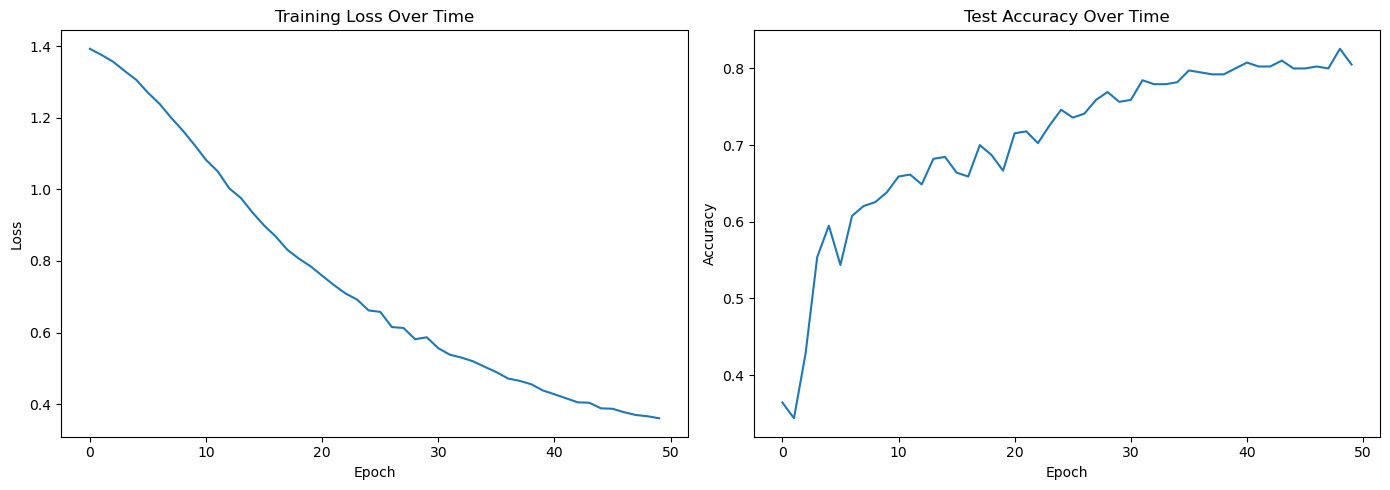

In [46]:
# Training curves (loss and accuracy over time)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                        # subplots(1, 2, ...) — creates 2 side-by-side plots

axes[0].plot(train_losses)                                              # plot — draws the loss values across all 50 epochs
axes[0].set_title("Training Loss Over Time")                            # set_title — labels this subplot
axes[0].set_xlabel("Epoch")                                             # set_xlabel — labels x-axis
axes[0].set_ylabel("Loss")                                              # set_ylabel — labels y-axis

axes[1].plot(test_accuracies)                                           # plot — draws the test accuracy values across all 50 epochs
axes[1].set_title("Test Accuracy Over Time")                            # set_title — labels this subplot
axes[1].set_xlabel("Epoch")                                             # set_xlabel — labels x-axis
axes[1].set_ylabel("Accuracy")                                          # set_ylabel — labels y-axis

plt.tight_layout()                                                       # tight_layout — adjusts spacing
plt.savefig("../outputs/figures/training_curves.png", dpi=150)         # savefig — saves for your report
plt.show()                                                                # show — displays it

## iNterpret

In [47]:
# Pull together summary statistics for the interpretation
print("=" * 60)                                                        # print — a visual divider line, purely for readability in the output
print("SUMMARY OF FINDINGS")                                           # print — section header
print("=" * 60)                                                        # print — closing divider

print(f"\nDataset: {len(final_df)} clips (balanced subset from FakeAVCeleb)")  # print — restates our final dataset size for context
print(f"Model: ResNet18 (image) + Wav2Vec2 (audio) frozen features + trained MLP classifier")  # print — restates the architecture

print(f"\nOverall test accuracy: {test_accuracies[-1]:.2%}")           # print — our headline result, formatted as a percentage

print("\nPer-class F1 scores (from classification_report):")           # print — header
report_dict = classification_report(y_test, final_preds, target_names=label_encoder.classes_, output_dict=True)  # classification_report(..., output_dict=True) — same report as before, but returned as a Python dictionary instead of printed text, so we can extract specific numbers
for cls in label_encoder.classes_:                                     # for cls in label_encoder.classes_ — loop through each of our 4 category names
    f1 = report_dict[cls]['f1-score']                                  # report_dict[cls]['f1-score'] — pulls out just this class's F1 score from the dictionary
    print(f"  {cls}: {f1:.2f}")                                        # print — displays it cleanly

print(f"\nDuration confound: FakeVideo-FakeAudio clips averaged {duration_df[duration_df['type']=='FakeVideo-FakeAudio']['duration'].mean():.2f}s")  # print — recalls our Explore finding about the shorter duration in this category
print(f"vs. {duration_df[duration_df['type']!='FakeVideo-FakeAudio']['duration'].mean():.2f}s for other categories (ANOVA p=7.83e-56)")  # print — comparison, restating statistical significance

SUMMARY OF FINDINGS

Dataset: 1950 clips (balanced subset from FakeAVCeleb)
Model: ResNet18 (image) + Wav2Vec2 (audio) frozen features + trained MLP classifier

Overall test accuracy: 80.51%

Per-class F1 scores (from classification_report):
  FakeVideo-FakeAudio: 0.90
  FakeVideo-RealAudio: 0.71
  RealVideo-FakeAudio: 0.90
  RealVideo-RealAudio: 0.71

Duration confound: FakeVideo-FakeAudio clips averaged 4.58s
vs. 6.39s for other categories (ANOVA p=7.83e-56)


In [48]:
# Define the full end-to-end inference function
def predict_video(video_path):
    # predict_video — takes a path to any video file, returns predicted category + confidence scores; this is the core function our Gradio demo will call
    try:                                                                # try — wraps everything so a bad/unusual upload doesn't crash the demo
        # --- Extract face frames ---
        cap = cv2.VideoCapture(video_path)                              # VideoCapture — opens the uploaded video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))          # CAP_PROP_FRAME_COUNT — total frames in this video

        if total_frames <= 0:                                           # if total_frames <= 0 — guard against unreadable/corrupt uploads
            cap.release()                                                # release — close the file
            return "Error: Could not read video file", {}               # return — an error message and empty scores dict

        frame_indices = np.linspace(0, total_frames - 1, 5, dtype=int)  # linspace — same 5-evenly-spaced-frames approach as Scrub

        frame_embeddings = []                                            # frame_embeddings — collects embeddings from each successfully-processed frame
        for frame_idx in frame_indices:                                 # for frame_idx in frame_indices — loop through our 5 chosen frame positions
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)                  # CAP_PROP_POS_FRAMES — jump to this specific frame
            ret, frame = cap.read()                                     # read() — grab that frame
            if not ret:                                                  # if not ret — skip if it failed to read
                continue                                                 # continue — move to next frame

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)              # cvtColor — convert to grayscale for face detection
            faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)  # detectMultiScale — find faces in this frame

            if len(faces) > 0:                                          # if len(faces) > 0 — only proceed if a face was found
                x, y, w, h = faces[0]                                    # faces[0] — take the first detected face
                face_crop = frame[y:y+h, x:x+w]                         # frame[y:y+h, x:x+w] — crop just the face region
                face_crop = cv2.resize(face_crop, (224, 224))           # resize — standardize to 224x224, matching our training pipeline

                img_tensor = image_transform(face_crop).unsqueeze(0)    # image_transform + unsqueeze — same preprocessing as training
                with torch.no_grad():                                   # no_grad — no gradient tracking needed
                    emb = resnet(img_tensor).flatten()                  # resnet(...) — extract this frame's embedding
                frame_embeddings.append(emb)                            # append — add to our collection

        cap.release()                                                    # release — close the video file

        if len(frame_embeddings) == 0:                                  # if len == 0 — no faces detected in any of the 5 frames
            return "Error: No face detected in video", {}                # return — clear error message for the user

        image_embedding = torch.stack(frame_embeddings).mean(dim=0)     # stack + mean — same averaging approach as training

        # --- Extract audio ---
        video_clip = VideoFileClip(video_path)                          # VideoFileClip — opens the video to access its audio track
        audio = video_clip.audio                                        # video_clip.audio — extracts the audio portion

        if audio is None:                                                # if audio is None — this video has no audio track at all
            video_clip.close()                                           # close — release resources
            return "Error: Video has no audio track", {}                 # return — clear error message

        temp_audio_path = "../data/processed/temp_inference_audio.wav"   # temp_audio_path — a temporary file to hold the extracted audio, reused each time
        audio.write_audiofile(temp_audio_path, logger=None)              # write_audiofile — saves the audio, logger=None silences verbose output
        video_clip.close()                                               # close — release the video file

        y, sr = librosa.load(temp_audio_path, sr=expected_sample_rate)   # librosa.load — reads and resamples the audio, same as training
        waveform = torch.from_numpy(y).unsqueeze(0)                      # from_numpy + unsqueeze — convert to the tensor format Wav2Vec2 expects

        with torch.no_grad():                                            # no_grad — no gradient tracking needed
            audio_features, _ = wav2vec_model.extract_features(waveform)  # extract_features — run through Wav2Vec2
            audio_embedding = audio_features[-1].mean(dim=1).flatten()  # last layer, averaged over time, flattened

        # --- Combine and classify ---
        combined = torch.cat([image_embedding, audio_embedding]).unsqueeze(0)  # cat + unsqueeze — combine both embeddings and add a batch dimension for the classifier

        model.eval()                                                     # eval() — evaluation mode
        with torch.no_grad():                                            # no_grad — no gradient tracking needed
            output = model(combined)                                    # model(...) — run our trained classifier
            probabilities = torch.softmax(output, dim=1).flatten()      # softmax — converts raw scores into proper probabilities that sum to 1, easier to interpret as "confidence"

        predicted_idx = torch.argmax(probabilities).item()               # argmax — the category with the highest probability; .item() converts to a plain number
        predicted_label = label_encoder.classes_[predicted_idx]          # classes_[predicted_idx] — converts the number back into the actual category name

        confidence_dict = {                                              # confidence_dict — builds a dictionary of category:probability pairs, the format Gradio's label display expects
            label_encoder.classes_[i]: float(probabilities[i])           # label_encoder.classes_[i] — category name; float(probabilities[i]) — its probability as a plain number
            for i in range(len(label_encoder.classes_))                  # for i in range(...) — loop through all 4 categories
        }

        return predicted_label, confidence_dict                          # return — the top prediction and the full confidence breakdown

    except Exception as e:                                               # except Exception as e — catches any unexpected error
        return f"Error: {str(e)}", {}                                    # return — shows the actual error message, useful for debugging

print("Inference function defined")                                      # print — confirmation

Inference function defined


In [49]:
# Test the inference function on a real clip from our dataset
# iloc[100] — pick a different clip than before, just to test on a fresh example

test_video_full_path = "../data/raw/FakeAVCeleb_v1.2/"                 # test_video_full_path — we need to reconstruct the original video path, since our inference function expects a raw video file, not pre-extracted frames/audio

# Find the original video path from our subset metadata
original_row = subset_df[subset_df['clip_id'].str.contains(str(100))].iloc[0] if 'clip_id' in subset_df.columns else None  # this is a fallback in case clip_id isn't in subset_df — we'll use final_df's zip_path instead below

test_video_path = "../data/raw/" + final_df.iloc[100]['zip_path']      # zip_path — final_df still has this column from Scrub, pointing to the actual video file location

print("Testing inference on:", test_video_path)                        # print — shows exactly which file we're testing

predicted_label, confidence_dict = predict_video(test_video_path)      # predict_video(...) — runs our full pipeline on this one real video

print("\nPredicted label:", predicted_label)                           # print — the model's top prediction
print("\nConfidence scores:")                                          # print — header
for label, conf in confidence_dict.items():                            # for label, conf in confidence_dict.items() — loop through all 4 category probabilities
    print(f"  {label}: {conf:.2%}")                                    # print — displays each as a percentage

print(f"\nActual label: {final_df.iloc[100]['type']}")                 # print — the true category, so we can check if the prediction is correct

Testing inference on: ../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/Caucasian (American)/men/id00062/00278.mp4

Predicted label: RealVideo-RealAudio

Confidence scores:
  FakeVideo-FakeAudio: 0.17%
  FakeVideo-RealAudio: 43.87%
  RealVideo-FakeAudio: 0.31%
  RealVideo-RealAudio: 55.64%

Actual label: RealVideo-RealAudio


In [62]:
example_paths = []                                                       # example_paths — will hold one file path per category

for category in final_df['type'].unique():                               # for category in final_df['type'].unique() — loop through all 4 categories
    sample = final_df[final_df['type'] == category].sample(1)            # sample(1) — picks ONE random clip from this category
    full_path = "../data/raw/" + sample.iloc[0]['zip_path']               # full_path — build the file path
    example_paths.append([full_path])                                    # append — add to our list

for p in example_paths:                                                   # print — verify what got picked
    print(p)

['../data/raw/FakeAVCeleb_v1.2/RealVideo-RealAudio/Asian (South)/men/id08457/00417.mp4']
['../data/raw/FakeAVCeleb_v1.2/RealVideo-FakeAudio/Asian (East)/women/id09181/00048_fake.mp4']
['../data/raw/FakeAVCeleb_v1.2/FakeVideo-RealAudio/African/women/id01532/00065_id02838_wavtolip.mp4']
['../data/raw/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/Asian (South)/women/id06428/00043_id07008_wavtolip.mp4']


In [63]:
import gradio as gr                                                     # gradio — the library for building our interactive web demo

def gradio_predict(video_file):
    # gradio_predict — a thin wrapper around our predict_video function, adapted to Gradio's expected input/output format
    if video_file is None:                                              # if video_file is None — handle the case where no video was uploaded yet
        return "Please upload a video", {}                              # return — a friendly prompt instead of crashing

    predicted_label, confidence_dict = predict_video(video_file)        # predict_video(...) — reuse our exact same tested function from Cell 1

    return predicted_label, confidence_dict                             # return — pass both outputs through to Gradio's display

demo = gr.Interface(                                                     # gr.Interface — Gradio's main tool for building a simple input→output web UI
    fn=gradio_predict,                                                  # fn — the function to call whenever the user submits something
    inputs=gr.Video(label="Upload a video clip"),                       # inputs — defines the UI input: a video upload widget with a label
    outputs=[                                                            # outputs — defines what to display after prediction; a list since we return two things
        gr.Textbox(label="Predicted Category"),                        # Textbox — displays our top predicted label as plain text
        gr.Label(label="Confidence Scores", num_top_classes=4)         # Label — Gradio's built-in component for showing a ranked list of category:confidence pairs, num_top_classes=4 shows all our categories
    ],
    title="Multi-Modal Deepfake Detector",                              # title — the heading shown at the top of the demo page
    description="Upload a short video clip to classify it as real or fake video/audio combination. Model: ResNet18 + Wav2Vec2 features, trained on a balanced subset of FakeAVCeleb.",  # description — explanatory text shown below the title
    examples=example_paths,                                             # examples — now shows all 4 category examples (one real/fake video/audio combination each) instead of just one
)

demo.launch(allowed_paths=["../data/raw"])                              # allowed_paths — tells Gradio it's safe to serve files from this folder too, needed since our example videos live outside the default allowed locations

/opt/anaconda3/envs/deepfake/lib/python3.10/site-packages/gradio/components/video.py:303: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/opt/anaconda3/envs/deepfake/lib/python3.10/site-packages/gradio/components/video.py:303: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/opt/anaconda3/envs/deepfake/lib/python3.10/site-packages/gradio/components/video.py:303: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/opt/anaconda3/envs/deepfake/lib/python3.10/site-packages/gradio/components/video.py:303: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [61]:
demo.close()

Closing server running on port: 7860
